# Chapter 5 notes



## Topic 1 — Joint probabilities and dataset likelihood

This beginner-focused note explains Equation 5.2 from [Chapter 5: Loss functions](../chapter-05-loss-functions.pdf), book page 58 (PDF page 3):

$$
\Pr(y_1,y_2,\ldots,y_I\mid x_1,x_2,\ldots,x_I)
=\prod_{i=1}^{I}\Pr(y_i\mid x_i).
$$

In plain language: **the probability of all observed targets together is calculated by multiplying the probability assigned to each target.** The equality uses an independence assumption that we will unpack below.

> The large symbol $\prod$ is the Greek capital letter pi. It means **multiply a sequence of terms**. It may look like a capital $Y$ in some fonts, but it is not the variable $Y$.


### 1.1 Why are there many x's and y's?

A training dataset contains many examples. Example $i$ consists of one input $x_i$ and its matching target $y_i$.

| Example index | Input | Matching target |
|---:|---|---|
| $1$ | $x_1$ | $y_1$ |
| $2$ | $x_2$ | $y_2$ |
| $3$ | $x_3$ | $y_3$ |
| $\vdots$ | $\vdots$ | $\vdots$ |
| $I$ | $x_I$ | $y_I$ |

Here, $i$ identifies one dataset row, and $I$ is the total number of rows. Therefore:

- $x_1$ is the first input and $y_1$ is its correct target.
- $x_2$ is the second input and $y_2$ is its correct target.
- $x_I$ is the last input and $y_I$ is its correct target.

These symbols normally describe **many input–target pairs**, not many targets belonging to one input. An individual $x_i$ can itself be a vector, image, or other complex object.


### 1.2 Reading the left side

The left side is

$$
\Pr(y_1,y_2,\ldots,y_I\mid x_1,x_2,\ldots,x_I).
$$

Read the vertical bar $\mid$ as **given**. Read the commas between the targets roughly as **and**. The whole expression asks:

> Given all the training inputs, how probable is it that we observe target $y_1$ **and** target $y_2$ **and** all the remaining targets through $y_I$?

This is a **joint conditional probability**:

- **joint** because it concerns all targets together;
- **conditional** because the inputs are already given.

The values $y_i$ are the observed targets. They are not themselves the probabilities. The model assigns a probability (or probability density) to each observed target.


### 1.3 Expanding the product for three examples

The right side uses product notation:

$$
\prod_{i=1}^{I}\Pr(y_i\mid x_i).
$$

The lower part, $i=1$, says to start with the first example. The upper part, $I$, says to stop after the final example.

If the dataset has three examples, so $I=3$, then

$$
\prod_{i=1}^{3}\Pr(y_i\mid x_i)
=\Pr(y_1\mid x_1)\times\Pr(y_2\mid x_2)\times\Pr(y_3\mid x_3).
$$

Each term uses a matching pair:

- first target with first input: $\Pr(y_1\mid x_1)$;
- second target with second input: $\Pr(y_2\mid x_2)$;
- third target with third input: $\Pr(y_3\mid x_3)$.

The product symbol is therefore shorthand. It prevents the author from writing a very long multiplication when the dataset contains thousands of examples.


### 1.4 Why can the joint probability become a product?

Equation 5.2 assumes that the training targets are **conditionally independent given their inputs**. In this context, that means:

> After the inputs and model are fixed, learning the target for one training example does not change the model's probability for another example's target.

Under this assumption, the probability of observing all targets together factors into one probability per example:

$$
\underbrace{\Pr(y_1,y_2,\ldots,y_I\mid x_1,x_2,\ldots,x_I)}_{\text{all targets together}}
=\underbrace{\prod_{i=1}^{I}\Pr(y_i\mid x_i)}_{\text{multiply one term per example}}.
$$

This is a **modeling assumption**, not a claim that real-world data can never be related. For example, two neighboring video frames may clearly be related. The assumption gives us a practical way to score the dataset example by example.

> The neural network parameters are shared by all examples but are left implicit in Equation 5.2. Each probability is produced using the same fitted model.


### 1.5 Numerical example

Imagine three email inputs. Each $y_i$ is the observed label for its email. Suppose the model assigns the following probabilities to those observed labels:

| Pair | Meaning | Probability assigned to observed target |
|---|---|---:|
| $(x_1,y_1)$ | First email and its label | $\Pr(y_1\mid x_1)=0.90$ |
| $(x_2,y_2)$ | Second email and its label | $\Pr(y_2\mid x_2)=0.80$ |
| $(x_3,y_3)$ | Third email and its label | $\Pr(y_3\mid x_3)=0.50$ |

Using Equation 5.2, the probability assigned to the complete set of observed labels is

$$
0.90\times0.80\times0.50=0.36.
$$

This product is the dataset's **likelihood** under the model. A low probability for even one observed target reduces the product. Training therefore tries to adjust the shared model parameters so that the observed targets collectively receive greater likelihood.


### 1.6 Compact mental model

When you see Equation 5.2, translate it in this order:

1. There are $I$ dataset rows.
2. Row $i$ contains input $x_i$ and matching target $y_i$.
3. $\Pr(y_i\mid x_i)$ scores the observed target for row $i$.
4. $\prod$ multiplies those scores across all rows.
5. The multiplication is permitted by the conditional-independence assumption.

In one sentence:

> **Score every observed target using its matching input, then multiply all those scores to obtain the likelihood of the complete dataset.**

The chapter next takes the logarithm of this product. Logs turn multiplication into addition:

$$
\log\!\left(\prod_{i=1}^{I}\Pr(y_i\mid x_i)\right)
=\sum_{i=1}^{I}\log\Pr(y_i\mid x_i).
$$

That conversion is the bridge from dataset likelihood to the negative log-likelihood loss.


## Topic 2 — $\arg\max$ and inference



### 2.1 What is $\arg\max$ searching?

The operation $\arg\max$ means **find the argument (input) where a function reaches its largest value**. It returns the location of the maximum, not the maximum value itself.

The symbol written under $\arg\max$ identifies what is allowed to change:

| Expression | What changes? | What does it return? |
|---|---|---|
| $\arg\max_{\phi}\operatorname{likelihood}(\phi)$ | Network parameters $\phi$ | Best fitted parameters $\hat{\phi}$ |
| $\arg\max_y \Pr(y\mid x)$ | Possible output $y$ | Best point prediction $\hat{y}$ |

So $\arg\max$ has not changed its meaning. What changes is the variable being searched.



### 2.2 Training versus inference

During **training**, the inputs and observed targets are fixed, and we search over the model parameters:

$$
\hat{\phi}=\arg\max_{\phi}\operatorname{likelihood}(\phi).
$$

Read this as: *which parameter values make the observed training data most likely?*

During **inference**, the trained parameters and new input are fixed, and we search over possible outputs:

$$
\hat{y}=\arg\max_y \Pr(y\mid f[x,\hat{\phi}],\sigma^2).
$$

Read this as: *which possible output lies at the highest point of the predicted distribution?*

### 2.3 Equation 5.12: inference with a normal distribution

The network predicts the mean of a normal distribution:

$$
\mu=f[x,\hat{\phi}].
$$

In Equation 5.12, the following quantities remain fixed:

- the new input $x$;
- the trained parameters $\hat{\phi}$;
- the variance $\sigma^2$.

Only the candidate output $y$ is allowed to move. The expression $\arg\max_y$ searches along the predicted bell curve for its highest point. A normal distribution reaches its maximum at its mean $\mu$, so

$$
\hat{y}=\mu=f[x,\hat{\phi}].
$$

For example, if the model predicts $\mu=7.3$, then the bell curve is centered at $7.3$, its peak is at $7.3$, and the point prediction is $\hat{y}=7.3$. Changing $\sigma^2$ changes the width of the bell curve but does not move this peak.



### 2.4 Regression versus classification

In this regression section, $y$ is a continuous numerical output, not a class label. Therefore, Equation 5.12 chooses the most likely **output location**. In classification, a related expression can instead use $\arg\max$ to choose the most probable class label.

> Technical note: for continuous $y$, the normal distribution assigns a **probability density** rather than a nonzero probability to one exact point. For now, it is sufficient to read Equation 5.12 as: *find the peak of the predicted bell curve*.

## Topic 3 — Homoscedastic and heteroscedastic regression


### 3.1 Mean, variance, and uncertainty bands

A regression model can describe a normal distribution over the possible target $y$ rather than predicting only one number.

- The mean $\mu$ is the center of the distribution and becomes the point prediction.
- The standard deviation $\sigma$ describes the uncertainty width in the same units as $y$.
- The variance is $\sigma^2$.
- A band such as $\mu\pm2\sigma$ displays a range around the prediction.

The words **homoscedastic** and **heteroscedastic** describe whether this uncertainty width remains constant or changes with the input $x$:

| Model | Meaning | Uncertainty |
|---|---|---|
| Homoscedastic | Same spread | One shared $\sigma^2$ for every input |
| Heteroscedastic | Different spread | A different $\sigma^2(x)$ can be predicted for each input |

A useful mnemonic is: **homo means same; hetero means different; scedastic refers to spread.**


### 3.2 House-price example: same versus changing uncertainty

Imagine that $x$ contains information about a house and $y$ is its sale price. The predicted mean $\mu(x)$ is the model's best price estimate, while $\sigma(x)$ describes how uncertain that estimate is.

A **homoscedastic** model uses one uncertainty width for every kind of house:

| House | Predicted mean | Predicted uncertainty |
|---|---:|---:|
| Ordinary house | 300,000 USD | $\pm$20,000 USD |
| Unusual mansion | 2,000,000 USD | $\pm$20,000 USD |
| Small rural house | 100,000 USD | $\pm$20,000 USD |

The predicted prices change, but the uncertainty remains the same.

A **heteroscedastic** model can use a different uncertainty width for each input:

| House | Predicted mean | Predicted uncertainty |
|---|---:|---:|
| Ordinary house | 300,000 USD | $\pm$15,000 USD |
| Unusual mansion | 2,000,000 USD | $\pm$400,000 USD |
| Small rural house | 100,000 USD | $\pm$30,000 USD |

The unusual mansion receives a wider interval because there may be few comparable sales. The ordinary house receives a narrower interval because the available data make its price easier to predict.

> The mean answers **“What price do I predict?”** The variance answers **“How uncertain am I about that prediction?”**


### 3.3 Homoscedastic regression: constant uncertainty

The predicted mean changes with the input, but the variance is one shared number:

$$
\mu_i=f[x_i,\phi],\qquad \sigma_i^2=\sigma^2.
$$

The model can predict a different central value for every $x_i$, but it claims equal confidence everywhere. Ordinary least-squares regression makes this constant-variance assumption.

In the illustration below, the blue mean changes with $x$, while the vertical distance from the mean to the gray boundaries remains constant.


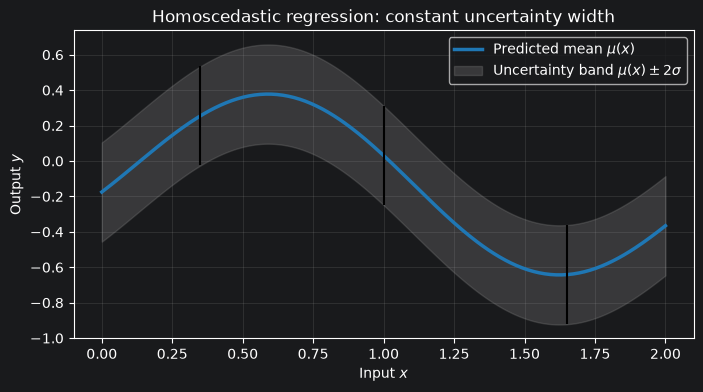

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.0, 2.0, 300)
mean = 0.45 * np.sin(3.2 * x - 0.4) - 0.12 * x
sigma = np.full_like(x, 0.14)  # The same uncertainty for every input.

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, mean, color="tab:blue", linewidth=2.5, label=r"Predicted mean $\mu(x)$")
ax.fill_between(
    x,
    mean - 2 * sigma,
    mean + 2 * sigma,
    color="gray",
    alpha=0.3,
    label=r"Uncertainty band $\mu(x)\pm2\sigma$",
)
ax.vlines([0.35, 1.0, 1.65],
          np.interp([0.35, 1.0, 1.65], x, mean) - 2 * sigma[0],
          np.interp([0.35, 1.0, 1.65], x, mean) + 2 * sigma[0],
          color="black", linewidth=1.5)
ax.set(title="Homoscedastic regression: constant uncertainty width",
       xlabel=r"Input $x$", ylabel=r"Output $y$")
ax.legend(loc="upper right")
ax.grid(alpha=0.2)
plt.show()


### 3.4 Heteroscedastic regression: input-dependent uncertainty

The model predicts both the mean and the variance from the input:

$$
\mu_i=f_1[x_i,\phi],\qquad \sigma_i^2=f_2[x_i,\phi]^2.
$$

The two functions denote two outputs of the same network:

1. $f_1$ predicts the mean $\mu_i$.
2. $f_2^2$ predicts the variance $\sigma_i^2$.

The second output is squared because a variance cannot be negative. In practice, other positive transformations can also be used.

In the illustration below, both the blue mean and the gray uncertainty width change with $x$. Narrow regions represent more confident predictions; wide regions represent less confident predictions.


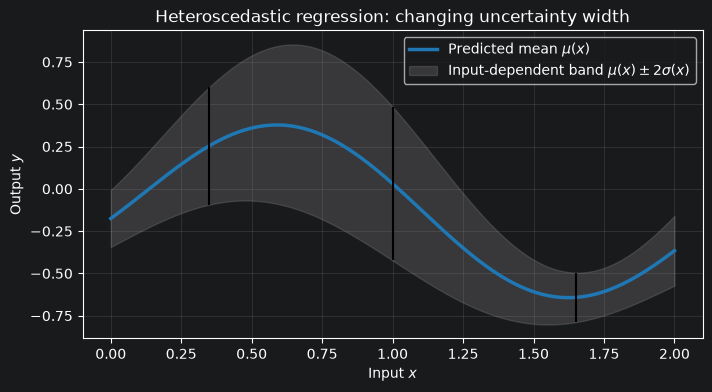

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.0, 2.0, 300)
mean = 0.45 * np.sin(3.2 * x - 0.4) - 0.12 * x
sigma = 0.07 + 0.18 * (0.5 + 0.5 * np.sin(3.3 * x - 1.0))

sample_x = np.array([0.35, 1.0, 1.65])
sample_mean = np.interp(sample_x, x, mean)
sample_sigma = np.interp(sample_x, x, sigma)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, mean, color="tab:blue", linewidth=2.5, label=r"Predicted mean $\mu(x)$")
ax.fill_between(
    x,
    mean - 2 * sigma,
    mean + 2 * sigma,
    color="gray",
    alpha=0.3,
    label=r"Input-dependent band $\mu(x)\pm2\sigma(x)$",
)
ax.vlines(sample_x,
          sample_mean - 2 * sample_sigma,
          sample_mean + 2 * sample_sigma,
          color="black", linewidth=1.5)
ax.set(title="Heteroscedastic regression: changing uncertainty width",
       xlabel=r"Input $x$", ylabel=r"Output $y$")
ax.legend(loc="upper right")
ax.grid(alpha=0.2)
plt.show()


### 3.5 Why the model cannot claim unlimited uncertainty

For one example, the normal negative log-likelihood has the following structure, up to a constant:

$$
\mathcal{L}_i=\frac{1}{2}\log \sigma_i^2+\frac{(y_i-\mu_i)^2}{2\sigma_i^2}+C.
$$

The two variable terms balance each other:

- Increasing $\sigma_i^2$ reduces the penalty caused by the squared residual $(y_i-\mu_i)^2$.
- However, $\log \sigma_i^2$ penalizes the model for claiming unnecessarily large uncertainty.

Without the logarithmic term, the model could reduce the residual penalty merely by predicting enormous variance. The full negative log-likelihood encourages the model to report uncertainty that matches the observed noise.


### 3.6 Compact mental model

> **Homoscedastic:** “My best answer changes with the input, but I claim the same uncertainty everywhere.”

> **Heteroscedastic:** “My best answer changes with the input, and some inputs are more predictable than others.”

To identify the model in a figure, focus on the uncertainty band rather than the mean line:

- Constant band width $\Rightarrow$ homoscedastic.
- Changing band width $\Rightarrow$ heteroscedastic.

For now, it is sufficient to understand the band-width distinction and that a heteroscedastic network predicts both $\mu(x)$ and $\sigma^2(x)$.


## Topic 4 — From softmax loss to the logarithm form


### 4.1 Start with the loss written using softmax

Equation 5.24 first writes the loss as

$$
\mathcal{L}[\phi]
=-\sum_{i=1}^{I}\log\left[\operatorname{softmax}_{y_i}\left(\mathbf{f}[x_i,\phi]\right)\right].
$$

Read this one training example at a time:

1. The network receives input $x_i$.
2. It produces $K$ raw outputs, one for each class.
3. Softmax converts those outputs into $K$ probabilities.
4. The subscript $y_i$ selects the probability assigned to the correct class.
5. The negative logarithm turns that probability into a loss.
6. The outer sum adds the losses for all $I$ training examples.

The important notation is

$$
\operatorname{softmax}_{y_i}\left(\mathbf{f}[x_i,\phi]\right).
$$

This does **not** mean that $y_i$ is multiplied by softmax. It means: **take component $y_i$ of the softmax output**, because $y_i$ is the correct class for example $i$.


### 4.2 Temporarily focus on one training example

The outer sum can make the derivation look more complicated than it is. Fix one example $i$ and define its logits by

$$
z_k=f_k[x_i,\phi].
$$

Here, $z_k$ is the raw network output for class $k$. The loss for this one example is

$$
\ell_i=-\log\left[\operatorname{softmax}_{y_i}(\mathbf{z})\right].
$$

If there are three classes, the network produces

$$
\mathbf{z}=[z_1,z_2,z_3].
$$

If the correct class is $y_i=2$, then softmax component $y_i$ means softmax component $2$. The numerator must therefore use $z_2$, not $z_1$ or $z_3$.


### 4.3 Substitute the definition of softmax

For any class $k$, softmax is

$$
\operatorname{softmax}_k(\mathbf{z})
=\frac{\exp(z_k)}{\sum_{k'=1}^{K}\exp(z_{k'})}.
$$

For the correct class $y_i$, replace $k$ with $y_i$:

$$
\operatorname{softmax}_{y_i}(\mathbf{z})
=\frac{\exp(z_{y_i})}{\sum_{k'=1}^{K}\exp(z_{k'})}.
$$

The two parts have different jobs:

- The numerator $\exp(z_{y_i})$ uses only the correct-class logit.
- The denominator $\sum_{k'=1}^{K}\exp(z_{k'})$ uses every class logit so that the resulting probabilities sum to one.

Now substitute this fraction into the one-example loss:

$$
\ell_i
=-\log\left[
\frac{\exp(z_{y_i})}{\sum_{k'=1}^{K}\exp(z_{k'})}
\right].
$$

At this point, we have only replaced the word “softmax” with its definition.


### 4.4 Use the logarithm-of-a-quotient rule

The first algebra rule is

$$
\log\left(\frac{a}{b}\right)=\log(a)-\log(b).
$$

In our expression,

$$
a=\exp(z_{y_i}),
\qquad
b=\sum_{k'=1}^{K}\exp(z_{k'}).
$$

Applying the rule gives

$$
\ell_i
=-\left[
\log\left(\exp(z_{y_i})\right)
-\log\left(\sum_{k'=1}^{K}\exp(z_{k'})\right)
\right].
$$

The negative sign remains outside the square brackets. This is important: it applies to the entire difference inside the brackets.


### 4.5 Cancel the logarithm and exponential

The second algebra rule is

$$
\log(\exp(a))=a.
$$

Therefore,

$$
\log\left(\exp(z_{y_i})\right)=z_{y_i}.
$$

Substituting this result gives

$$
\ell_i
=-\left[
z_{y_i}
-\log\left(\sum_{k'=1}^{K}\exp(z_{k'})\right)
\right].
$$

If we distribute the outer negative sign, the equivalent expression is

$$
\ell_i
=\log\left(\sum_{k'=1}^{K}\exp(z_{k'})\right)-z_{y_i}.
$$

In words:

> Compute the log-sum-exp of all class logits, then subtract the correct-class logit.


### 4.6 Replace the temporary logits and restore the dataset sum

We temporarily defined

$$
z_k=f_k[x_i,\phi].
$$

Therefore,

$$
z_{y_i}=f_{y_i}[x_i,\phi],
$$

and

$$
\sum_{k'=1}^{K}\exp(z_{k'})
=\sum_{k'=1}^{K}\exp\left(f_{k'}[x_i,\phi]\right).
$$

Finally, add the loss over all $I$ examples:

$$
\mathcal{L}[\phi]
=-\sum_{i=1}^{I}
\left(
f_{y_i}[x_i,\phi]
-\log\left[
\sum_{k'=1}^{K}\exp\left(f_{k'}[x_i,\phi]\right)
\right]
\right).
$$

This is the second form in Equation 5.24.

| Index | Job |
|---|---|
| $i$ | Visits every training example |
| $y_i$ | Identifies the correct class for example $i$ |
| $k'$ | Visits every possible class in the softmax denominator |

The symbol $k'$ is only a temporary summation index. The prime does not denote a derivative.


### 4.7 Numerical example and compact derivation

Suppose one example has three logits

$$
\mathbf{z}=[2,1,0],
$$

and the correct class is $y_i=2$. The correct-class logit is therefore $z_{y_i}=z_2=1$.

The softmax denominator is

$$
\exp(2)+\exp(1)+\exp(0)
\approx7.389+2.718+1
=11.107.
$$

The probability assigned to the correct class is

$$
p(y_i=2\mid x_i)
=\frac{\exp(1)}{11.107}
\approx0.245.
$$

Using the original softmax form,

$$
\ell_i=-\log(0.245)\approx1.407.
$$

Using the derived logarithm form,

$$
\ell_i=\log(11.107)-1\approx2.407-1=1.407.
$$

Both forms give the same loss.

The complete derivation is

$$
-\log\left(\operatorname{softmax}_{y_i}(\mathbf{z})\right)
=-\log\left[
\frac{\exp(z_{y_i})}{\sum_{k'=1}^{K}\exp(z_{k'})}
\right]
$$

$$
=-\left[
z_{y_i}-\log\left(\sum_{k'=1}^{K}\exp(z_{k'})\right)
\right]
=\log\left(\sum_{k'=1}^{K}\exp(z_{k'})\right)-z_{y_i}.
$$

For now, it is sufficient to remember three moves:

1. Replace softmax with its exponential fraction.
2. Use $\log(a/b)=\log(a)-\log(b)$.
3. Use $\log(\exp(a))=a$.
